In [1]:
from google.colab import files
uploaded = files.upload()

Saving adult_dataset.csv to adult_dataset.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage

In [3]:
df = pd.read_csv("adult_dataset.csv")
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39.0,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40.0,NaN,<=50K
1,50.0,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13.0,United-States,<=50K
2,38.0,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40.0,United-States,<=50K
3,53.0,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40.0,United-States,<=50K
4,28.0,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40.0,Cuba,<=50K


In [4]:
df.replace('?', np.nan, inplace=True)

# Drop income column
if 'income' in df.columns:
    df.drop('income', axis=1, inplace=True)

# Fill missing values
for col in df.columns:
    if df[col].dtype == 'object':
        df[col].fillna(df[col].mode()[0], inplace=True)
    else:
        df[col].fillna(df[col].median(), inplace=True)

/tmp/ipykernel_19287/3544913803.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
/tmp/ipykernel_19287/3544913803.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', tr

In [5]:
df_encoded = pd.get_dummies(df, drop_first=True)

In [7]:
# Convert boolean columns to integer (0 or 1) to avoid TypeError in quantile calculation
for col in df_encoded.columns:
    if df_encoded[col].dtype == 'bool':
        df_encoded[col] = df_encoded[col].astype(int)

Q1 = df_encoded.quantile(0.25)
Q3 = df_encoded.quantile(0.75)
IQR = Q3 - Q1

df_out = df_encoded[~((df_encoded < (Q1 - 1.5 * IQR)) | (df_encoded > (Q3 + 1.5 * IQR))).any(axis=1)]

In [8]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_out)

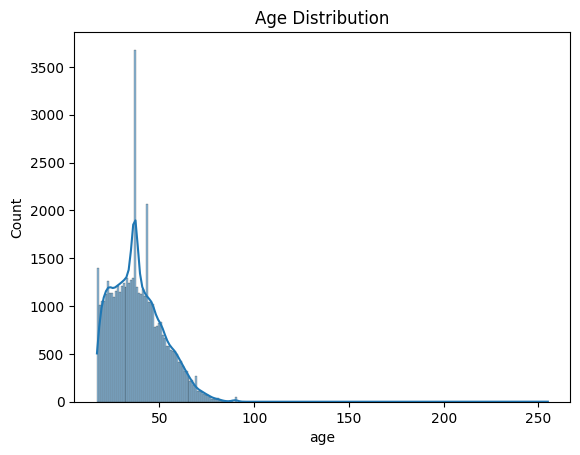

In [9]:
sns.histplot(df['age'], kde=True)
plt.title("Age Distribution")
plt.show()

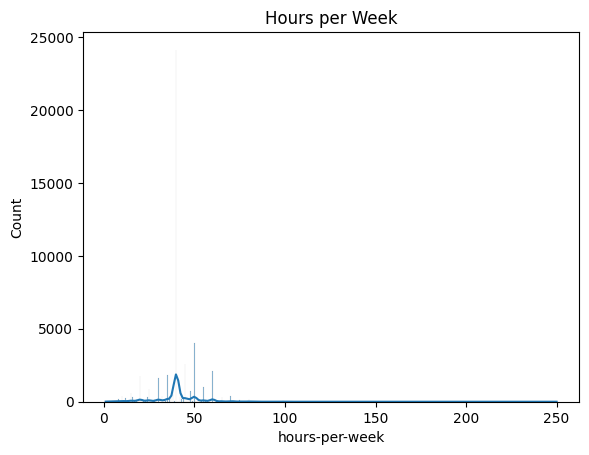

In [10]:
sns.histplot(df['hours-per-week'], kde=True)
plt.title("Hours per Week")
plt.show()

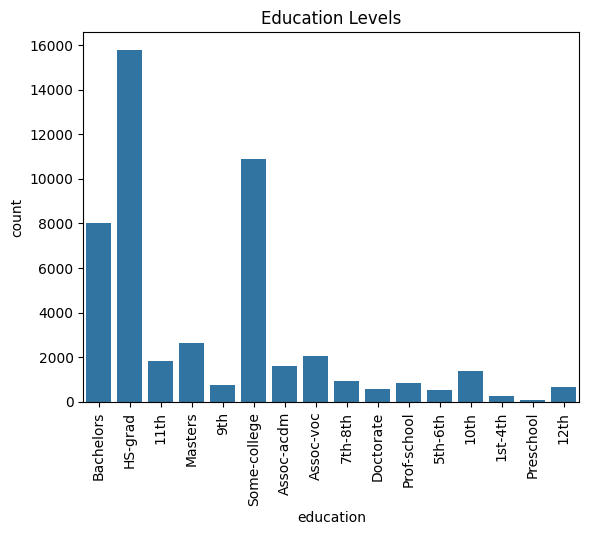

In [11]:
sns.countplot(x='education', data=df)
plt.xticks(rotation=90)
plt.title("Education Levels")
plt.show()

In [12]:
print("Capital Gain Skew:", df['capital-gain'].skew())
print("Capital Loss Skew:", df['capital-loss'].skew())

Capital Gain Skew: 11.894658996587948
Capital Loss Skew: 4.569808857738483


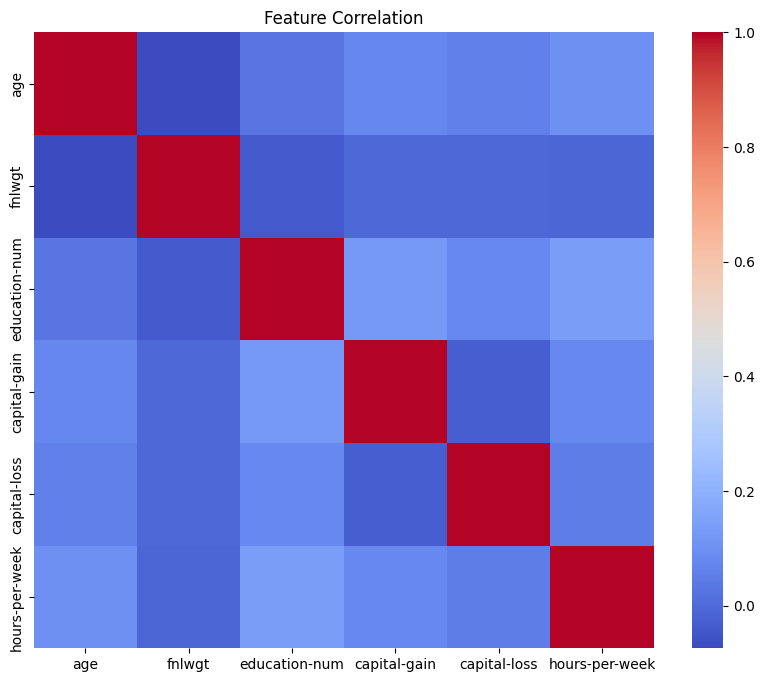

In [13]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm')
plt.title("Feature Correlation")
plt.show()

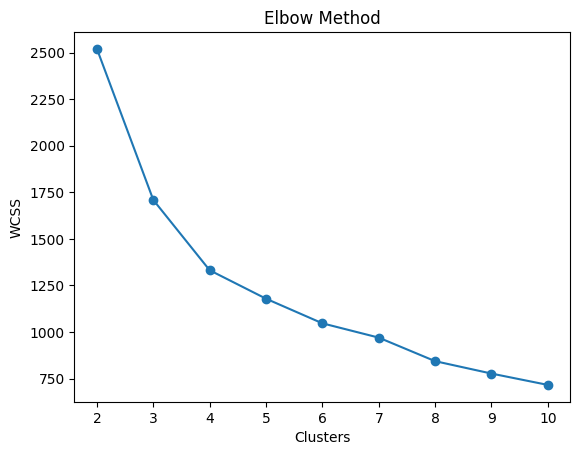

In [14]:
wcss = []
for i in range(2, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(2, 11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Clusters")
plt.ylabel("WCSS")
plt.show()

In [15]:
k = 4
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

print("Silhouette Score (KMeans):", silhouette_score(X_scaled, kmeans_labels))

Silhouette Score (KMeans): 0.37299019396829947


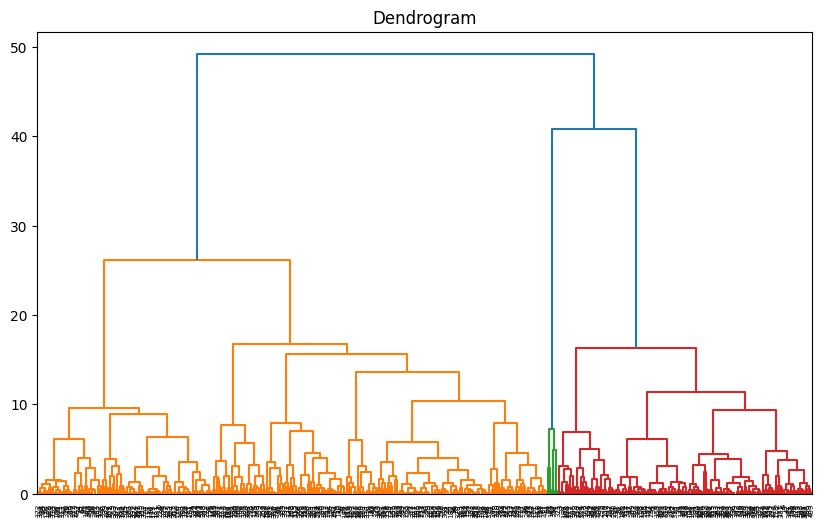

In [16]:
linked = linkage(X_scaled, method='ward')

plt.figure(figsize=(10,6))
dendrogram(linked)
plt.title("Dendrogram")
plt.show()

In [17]:
agg = AgglomerativeClustering(n_clusters=4)
agg_labels = agg.fit_predict(X_scaled)

print("Silhouette Score (Agglomerative):", silhouette_score(X_scaled, agg_labels))

Silhouette Score (Agglomerative): 0.35647119235011965


In [18]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=1.5, min_samples=5)
db_labels = dbscan.fit_predict(X_scaled)

print("DBSCAN Clusters:", set(db_labels))

DBSCAN Clusters: {np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(-1)}


In [19]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Explained Variance:", pca.explained_variance_ratio_)

Explained Variance: [0.34853693 0.2221861 ]


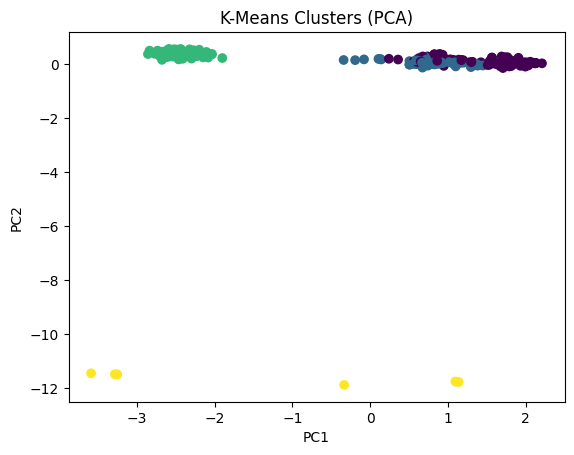

In [20]:
plt.scatter(X_pca[:,0], X_pca[:,1], c=kmeans_labels)
plt.title("K-Means Clusters (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

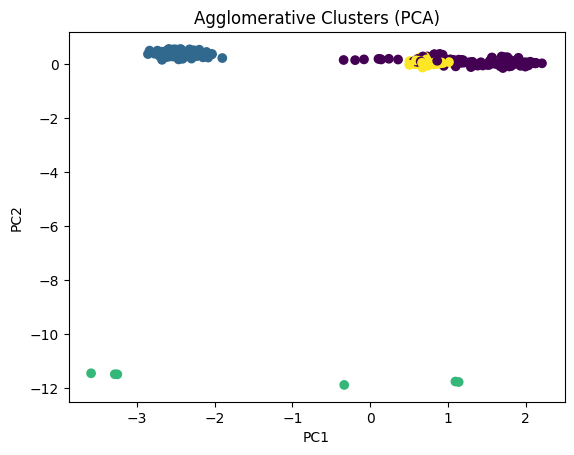

In [21]:
plt.scatter(X_pca[:,0], X_pca[:,1], c=agg_labels)
plt.title("Agglomerative Clusters (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [22]:
df_out['KMeans_Cluster'] = kmeans_labels
df_out.groupby('KMeans_Cluster').mean()

/tmp/ipykernel_19287/2165521516.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_out['KMeans_Cluster'] = kmeans_labels


,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,workclass_Local-gov,workclass_Never-worked,workclass_Private,workclass_Self-emp-inc,...,native-country_Portugal,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia
KMeans_Cluster,,,,,,,,,,,,,,,,,,,,,
0,30.062500,199627.662500,9.0,0.0,0.0,41.081250,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,46.280702,173342.657895,9.0,0.0,0.0,40.315789,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,41.109489,174366.218978,9.0,0.0,0.0,41.372263,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,42.166667,187966.000000,6.0,0.0,0.0,40.000000,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [23]:
df_out.to_csv("final_clustered_data.csv", index=False)